# Aircraft Engine Predictive Maintainance System
## Exploratory Analysis - NASA C-MAPSS FD001 Dataset

---

## 1. Project Overview

### What is Predictive Maintainance?

Traditional aircraft maintainance follows two strategies:

- **Reactive**: Fix after failure - dangerous and expensive
- **Scheduled**: Service on a calender - safe but wasteful

**Predictive Maintainance** is the smarter option: use real sensor data to predict *exactly* when a component fail, and service it at the optimal time.

---

### What is Remaining Useful Life (RUL)?

**RUL** = the number of operational cycles an engine can still run before failure.

**Example**: Engine has run 150 cycles, expected to fail at cycle 200 -> RUL = 50 cycles.

---

### Why Airlines Care About RUL Prediction

| Business Problem | Impact |
|---|---|
| Unplanned engine failure | $500,000+ per flight cancellation |
| Over-maintenance | Unnecessary labor + parts costs |
| Safety incidents | Reputational and regulatory consequences |

A well-calibrated RUL model can reduce maintenance costs by **10-25%** and dramatically improve safety margins.

---

### Dataset: NASA C-MAPSS FD001

| Property | Value |
|---|---|
| Dataset | FD001 |
| Operating Conditions | 1 (Sea Level) |
| Fault Mode | HPC Degradation |
| Training Engines | 100 |
| Test Engines | 100 |


---

## 2. Dataset Overview

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f8f9fa','font.size':11,'axes.titlesize':13,'axes.titleweight':'bold'})

In [7]:
cols = ['engine_id','cycle','op_set_1','op_set_2','op_set_3']
cols += [f'sensor_{i}' for i in range(1,22)]

train_df = pd.read_csv(r'data/raw/train_FD001.txt', sep=r'\s+', header=None, names=cols)
test_df  = pd.read_csv(r'data/raw/test_FD001.txt',  sep=r'\s+', header=None, names=cols)
rul_true = pd.read_csv(r'data/raw/RUL_FD001.txt',  header=None, names=['RUL'])

In [8]:
print('TRAINING DATASET')
print(f'Shape: {train_df.shape[0]} rows X {train_df.shape[1]} columns')
print(f'Unique Engines: {train_df.engine_id.nunique()}')
print(f'Total Cycles: {train_df.cycle.sum():,}')
print(f'Avg Cycles/Eng: {train_df.groupby("engine_id")["cycle"].max().mean():.0f}')
print()

print('TESTING DATASET')
print(f'Shape: {test_df.shape[0]} rows X {test_df.shape[1]} columns')
print(f'Unique Engines: {test_df.engine_id.nunique()}')

train_df.head(5)

TRAINING DATASET
Shape: 20631 rows X 26 columns
Unique Engines: 100
Total Cycles: 2,244,815
Avg Cycles/Eng: 206

TESTING DATASET
Shape: 13096 rows X 26 columns
Unique Engines: 100


,engine_id,cycle,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### Observations

- **Training set**: 20,631 rows across 100 engines with full run-to-failure trajectories.
- **Test set**: 13,096 rows across 100 engines - truncated (engine has not yet failed).
- Each row = one operational cycle of one engine.

### Business Interpretation

Training engines ran to failure, giving ground-truth labels. The test set mimics the real world: observe sensor readings up to now and predict how many cycles remain.

### Impact on Model Development

100 engines x full lifecycles = sufficient diversity. 21 sensors provide rich multi-variate signals. The asymmetry between train (full life) and test (truncated) requires careful target engineering.

___

## 3. Data Quality Assessment

In [9]:
op_cols = ['op_set_1','op_set_2','op_set_3']
sensor_cols = [f'sensor_{i}' for i in range(1,22)]

print('MISSING VALUES - Training Set')
missing = train_df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found")

print()

print('MISSING VALUES - Testing Set')
missing = test_df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found")

print()

print(f'Duplicate Rows (train): {train_df.duplicated().sum()}')
print(f'Duplicate Rows (test): {test_df.duplicated().sum()}')

print()

print('DATA TYPES (Training Set)')
print(train_df.dtypes.value_counts().to_string())

print()

print('DATA TYPES (Testing Set)')
print(test_df.dtypes.value_counts().to_string())

MISSING VALUES - Training Set
No missing values found

MISSING VALUES - Testing Set
No missing values found

Duplicate Rows (train): 0
Duplicate Rows (test): 0

DATA TYPES (Training Set)
float64    22
int64       4

DATA TYPES (Testing Set)
float64    22
int64       4


### Key Findings

- **No missing values** in either dataset - clean, simulation-derived data
- **No duplicate rows** - data integrity is intact
- **All columns are numeric** - ready for analysis without encoding


### Risks
- **Sensor Noise**: Dataset documentation explicitly states noise is present. Naive models may overfit noise.
- **Engine-to-Engine variation**: Engines start with different wear levels. Absolute sensor values can be misleading without per-engine normalization.

### Impact on Modelling
No imputation required. Focus should be on **Noise Handling**, **Normalization**, **Feature Selection**

___

## 4. Remaining Useful Life (RUL) Generation

In [10]:
max_cycle = train_df.groupby('engine_id')['cycle'].transform('max')
train_df['RUL'] = max_cycle - train_df.cycle

print('RUL Generation Formula')
print('RUL = Max Life Cycle for Engine - Current Cycle')

RUL Generation Formula
RUL = Max Life Cycle for Engine - Current Cycle


### Business Exploration

Think of RUL like a fuel gauge - but showing remaining operational cycles instead of remaining fuel. When RUL = 0, the engine needs immediate attention.
**RUL = Total Engine Life - Cycles already used**
Since training engines ran to failure, the maximum cycle is the failure point.

### Why RUL becomes the prediction target?
Predicting RUL is more actionable than binary fault condition.
- 'This engine has 47 cycles left' -> actionable maintainance planning.
- 'This engine might fail' -> no timeline, no actionable schedule.

---

## 5. RUL Distribution Analysis 

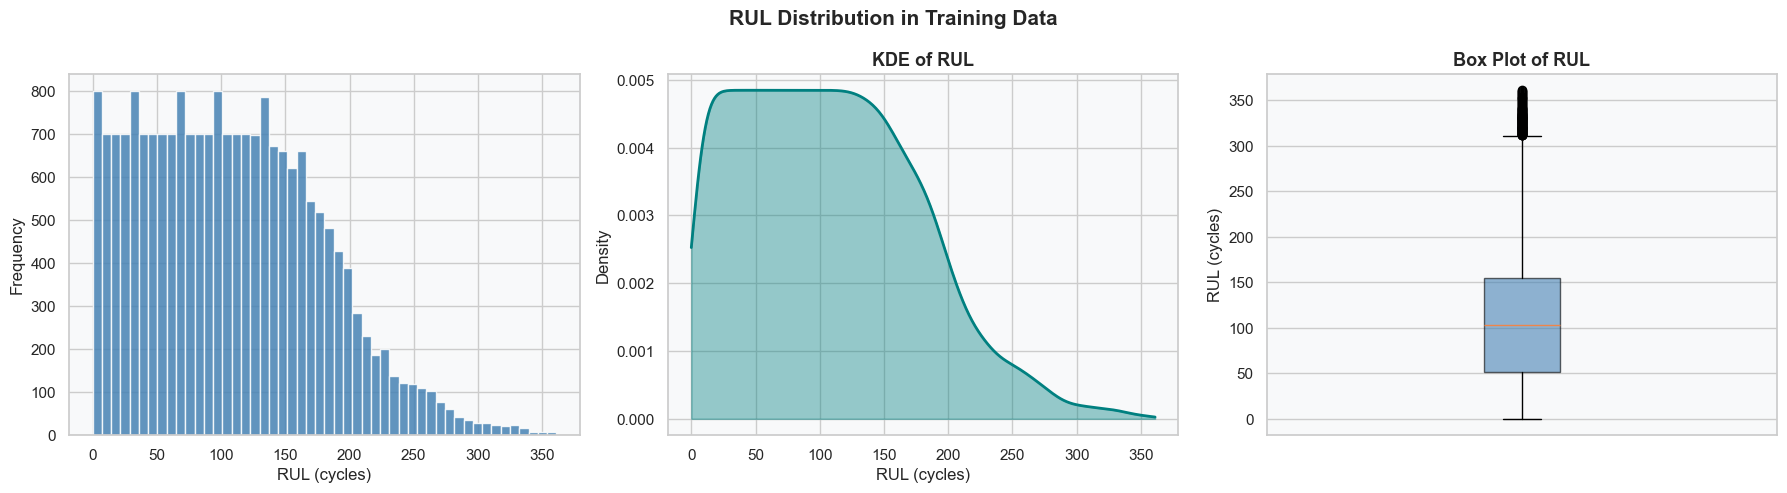


RUL SUMMARY STATS
count    20631.00
mean       107.81
std         68.88
min          0.00
25%         51.00
50%        103.00
75%        155.00
max        361.00

Skewness: 0.4999039652821549
Kurtosis: -0.21853910305057278


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'RUL Distribution in Training Data', fontsize=15, fontweight='bold')

axes[0].hist(train_df.RUL, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('RUL (cycles)')
axes[0].set_ylabel('Frequency')

rul_vals = train_df.RUL.values
kde = gaussian_kde(rul_vals)
x = np.linspace(0, rul_vals.max(), 300)

axes[1].fill_between(x, kde(x), alpha=0.4, color='teal')
axes[1].plot(x, kde(x), color='teal', linewidth=2)
axes[1].set_xlabel('RUL (cycles)')
axes[1].set_ylabel('Density')
axes[1].set_title('KDE of RUL')

axes[2].boxplot(train_df.RUL, vert=True, patch_artist=True, boxprops = dict(facecolor='steelblue', alpha=0.6))
axes[2].set_ylabel('RUL (cycles)')
axes[2].set_title('Box Plot of RUL')
axes[2].set_xticks([])

plt.tight_layout()
plt.show()


print()
print('RUL SUMMARY STATS')
print(train_df.RUL.describe().round(2).to_string())
print()
print(f'Skewness: {train_df.RUL.skew()}')
print(f'Kurtosis: {train_df.RUL.kurtosis()}')

### Key Observations

- The distribution is right-skewed: many rows with low RUL (near-failure)
- Most RUL values cluster below 200, with a long tail toward higher values.
- Mean RUL > Median RUL confirms positive skew.

### Model Implications

- **Imbalance**: Model sees disproportionately more near-failure data. Risk of bias towards shorter RUL predictions
- **Target Clipping**: Cap RUL at 125-130 cycles to focus learning on the degradation zone.

---

## 6. Engine Lifecycle Analysis

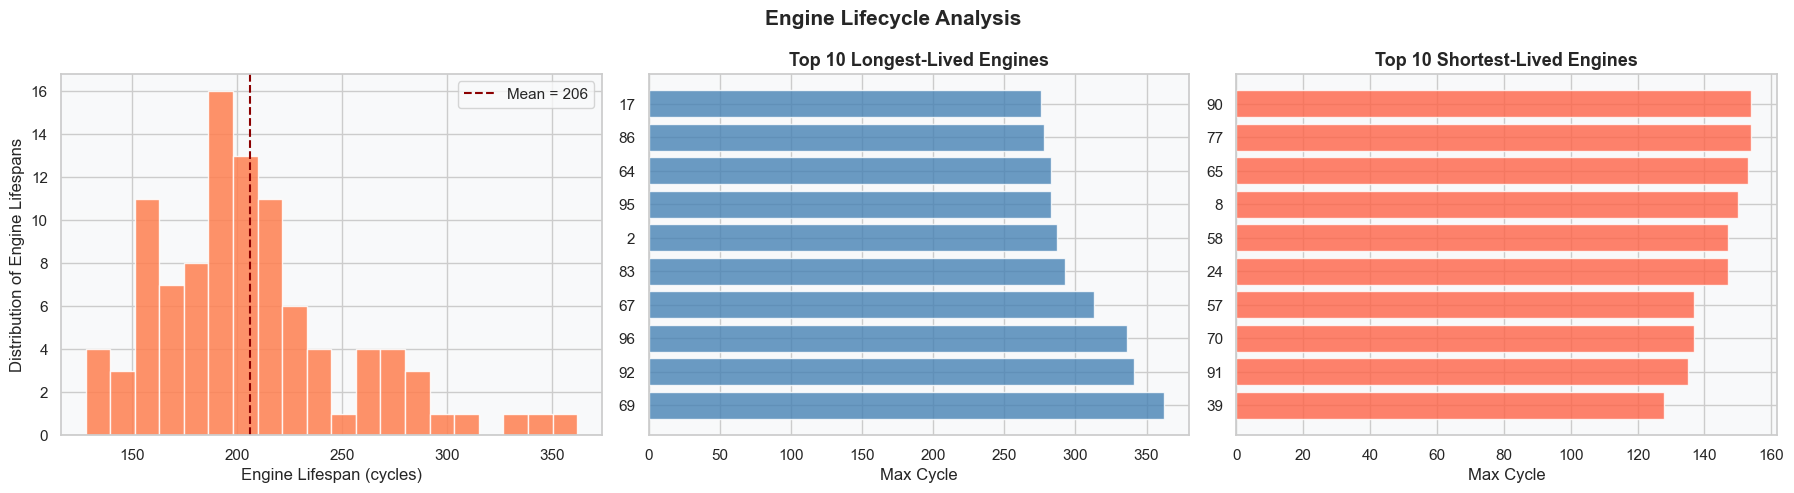

LIFFESPAN SUMMARY
count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0


In [12]:
engine_life = train_df.groupby('engine_id')['cycle'].max().reset_index()
engine_life.columns = ['engine_id','max_cycle']
engine_life = engine_life.sort_values('max_cycle')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Engine Lifecycle Analysis', fontweight='bold', fontsize=15)

axes[0].hist(engine_life.max_cycle, bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Engine Lifespan (cycles)')
axes[0].set_ylabel('Distribution of Engine Lifespans')
axes[0].axvline(engine_life['max_cycle'].mean(), color='darkred', linestyle='--', label=f'Mean = {engine_life.max_cycle.mean():.0f}')
axes[0].legend()

top10 = engine_life.nlargest(10, 'max_cycle')
axes[1].barh(top10['engine_id'].astype(str), top10['max_cycle'], color='steelblue', alpha=0.8)
axes[1].set_xlabel('Max Cycle')
axes[1].set_title('Top 10 Longest-Lived Engines')

bot10 = engine_life.nsmallest(10, 'max_cycle')
axes[2].barh(bot10['engine_id'].astype(str), bot10['max_cycle'], color='tomato', alpha=0.8)
axes[2].set_xlabel('Max Cycle')
axes[2].set_title('Top 10 Shortest-Lived Engines')

plt.tight_layout()
plt.show()

print('LIFFESPAN SUMMARY')
print(engine_life.max_cycle.describe().round(1).to_string())

### Business Interpretation

Engine lifespans vary considerably - some engine fail quickly while others run for hundred of cycles. This mirrors real-world fleet operations.
- **Short-lived engines** (<150 cycles): accelerated degradation - critical learning cases.
- **Long-lived engines** (>300 cycles): gradual healthy organization - useful baselines.

### Impact on Generalization
The model must generalize across a wide range of lifespans. Sequence-aware models (LSTM, GRU) handle this variablity better than static methods.

---
## 7. RUL Degradation Visualization

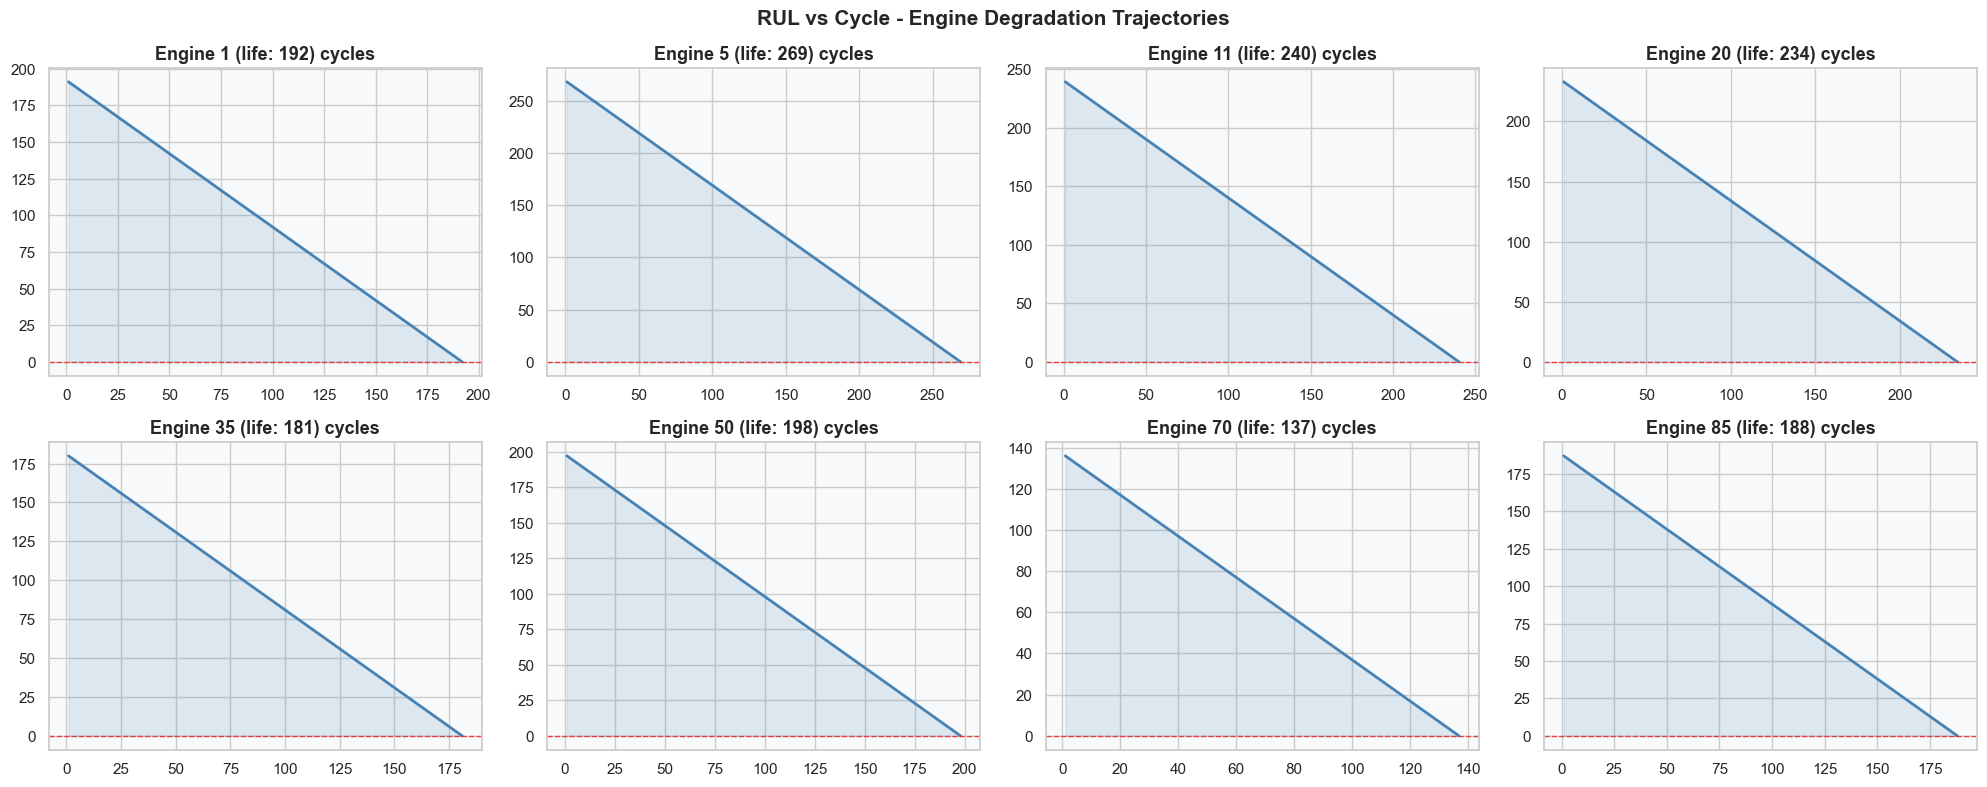

In [13]:
sample_engines = [1, 5, 11, 20, 35, 50, 70, 85]

fig, axes = plt.subplots(2, 4, figsize=(20,8))
fig.suptitle('RUL vs Cycle - Engine Degradation Trajectories', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, eid in enumerate(sample_engines):
    sub = train_df[train_df['engine_id'] == eid]

    axes[i].plot(sub['cycle'], sub['RUL'], color='steelblue', linewidth=2)
    axes[i].fill_between(sub['cycle'], sub['RUL'], alpha=0.15, color='steelblue')
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    axes[i].set_title(f'Engine {eid} (life: {sub["cycle"].max()}) cycles')

plt.tight_layout()
plt.show()

### Key Findings

- **Linear by construction**: RUL = max_cycle-cycle is linear by defination. This is a labelling artefact, not physical reality.
- Physics degradation is **nonlinear** - engines degrade slowly at first then accelerate near failure.
- This motivates **piecewise-linear** or **capped RUL labels**

### Modelling Implications
1. **Capped RUL**: Clip to max 125 cycles - forces model to focus on the degradation zone.
2. **Log-transform**: Compresses high-RUL range, puts more weight on near-failure predictions.
3. **Sequence models**: LSTM/GRU/Tranformers learn the temporal pattern leading to failure.

---
## 8. Operational Settings Analysis

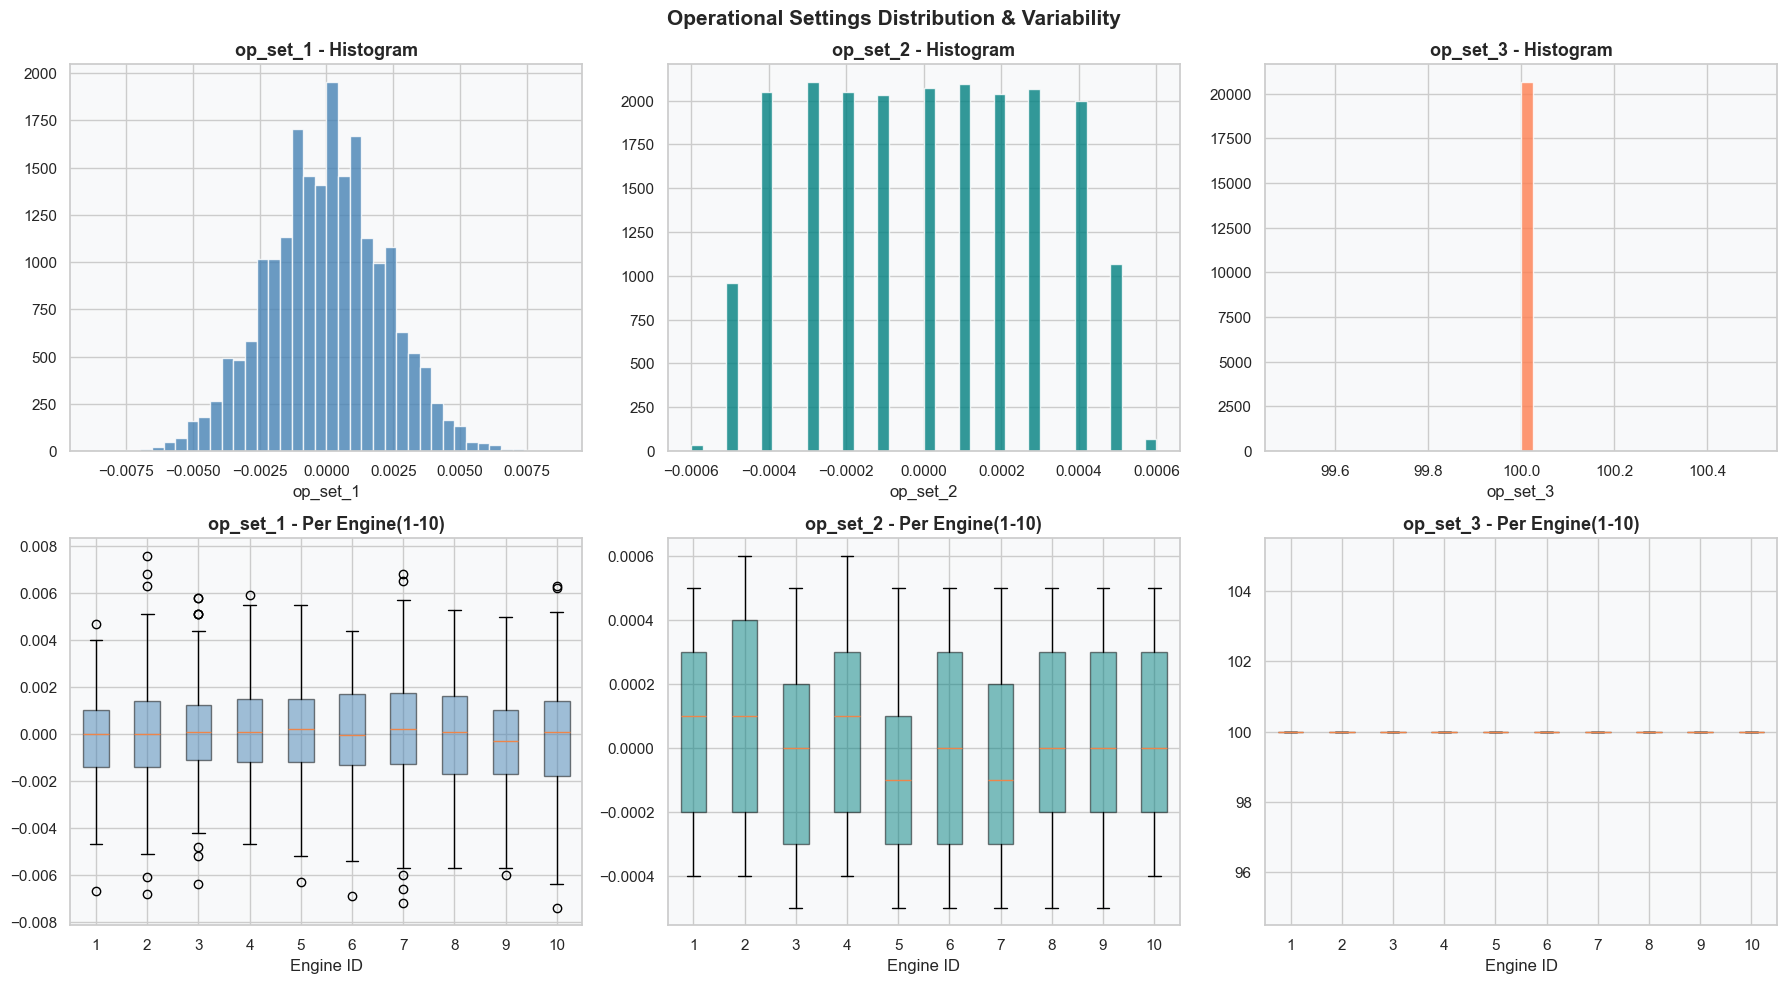

OPERATIONAL SETTINGS - SUMMARY
         op_set_1    op_set_2  op_set_3
count  20631.0000  20631.0000   20631.0
mean      -0.0000      0.0000     100.0
std        0.0022      0.0003       0.0
min       -0.0087     -0.0006     100.0
25%       -0.0015     -0.0002     100.0
50%        0.0000      0.0000     100.0
75%        0.0015      0.0003     100.0
max        0.0087      0.0006     100.0

COEFFICIENT OF VARIATION (std/|mean|) * 100
op_set_1: 2.47
op_set_2: 1.25
op_set_3: 0.00


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))
fig.suptitle('Operational Settings Distribution & Variability', fontsize=15, fontweight='bold')
colors = ['steelblue','teal','coral']

for i, col in enumerate(op_cols):
    axes[0, i].hist(train_df[col], bins=40, color=colors[i], alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{col} - Histogram')
    axes[0, i].set_xlabel(col)

    sample_data = [train_df[train_df['engine_id'] == e][col].values for e in range(1, 11)]
    axes[1, i].boxplot(sample_data, patch_artist=True, boxprops=dict(facecolor=colors[i], alpha=0.5))
    axes[1, i].set_title(f'{col} - Per Engine(1-10)')
    axes[1, i].set_xlabel('Engine ID')

plt.tight_layout()
plt.show()

print('OPERATIONAL SETTINGS - SUMMARY')
print(train_df[op_cols].describe().round(4).to_string())
print()
print('COEFFICIENT OF VARIATION (std/|mean|) * 100')

for col in op_cols:
    cv = train_df[col].std() / abs(train_df[col].mean() * 100 if train_df[col].mean() != 0 else float('inf'))
    print(f'{col}: {cv:.2f}')

### Business Insight

**FD001 uses a single operation condition (sea level).** The three operational settings are essentially constant:
- **op_set_1** and **op_set_2**: near-zero with very small variance - noise around a fixed point.
- **op_set_3**: fixed at 100.0 - a constant

### Feature Engineering Implications
- Drop **op_set_3** - constant, zero information
- **op_set_1** and **op_set_2** have minimum value for FD001 but may be useful for condition clustering in FD002/FD004.


---
## 9. Sensor Distribution Analysis

In [15]:
sensor_stats = train_df[sensor_cols].describe().T
sensor_stats['cv'] = (sensor_stats['std'] / sensor_stats['mean'].abs() * 100).round(2)
sensor_stats['range'] = sensor_stats['max'] - sensor_stats['min']

print('SENSOR VARIANCE ANALYSIS')
print(f'{"Sensor":<12} {"Mean":>12} {"Std":>10} {"CV%":>10} {"Range":>12}')
print('-' * 60)
for s in sensor_cols:
    row = sensor_stats.loc[s]
    print(f'{s:<12} {row["mean"]:>12.4f} {row["std"]:>10.4f} {row["cv"]:>10.2f} {row["range"]:>12.4f}')

const_sens = sensor_stats[sensor_stats['range'] < 1e-6].index.tolist()
low_var = sensor_stats[(sensor_stats['cv'] < 0.5) & (sensor_stats['range'] >= 1e-6)].index.tolist()
print(f'\nConstant sensors: {const_sens}')
print(f'Low-variance sensors (CV < 0.5%): {low_var}')

SENSOR VARIANCE ANALYSIS
Sensor               Mean        Std        CV%        Range
------------------------------------------------------------
sensor_1         518.6700     0.0000       0.00       0.0000
sensor_2         642.6809     0.5001       0.08       3.3200
sensor_3        1590.5231     6.1311       0.39      45.8700
sensor_4        1408.9338     9.0006       0.64      59.2400
sensor_5          14.6200     0.0000       0.00       0.0000
sensor_6          21.6098     0.0014       0.01       0.0100
sensor_7         553.3677     0.8851       0.16       6.2100
sensor_8        2388.0967     0.0710       0.00       0.6600
sensor_9        9065.2429    22.0829       0.24     222.8600
sensor_10          1.3000     0.0000       0.00       0.0000
sensor_11         47.5412     0.2671       0.56       1.6800
sensor_12        521.4135     0.7376       0.14       4.6900
sensor_13       2388.0962     0.0719       0.00       0.6800
sensor_14       8143.7527    19.0762       0.23     193.7800

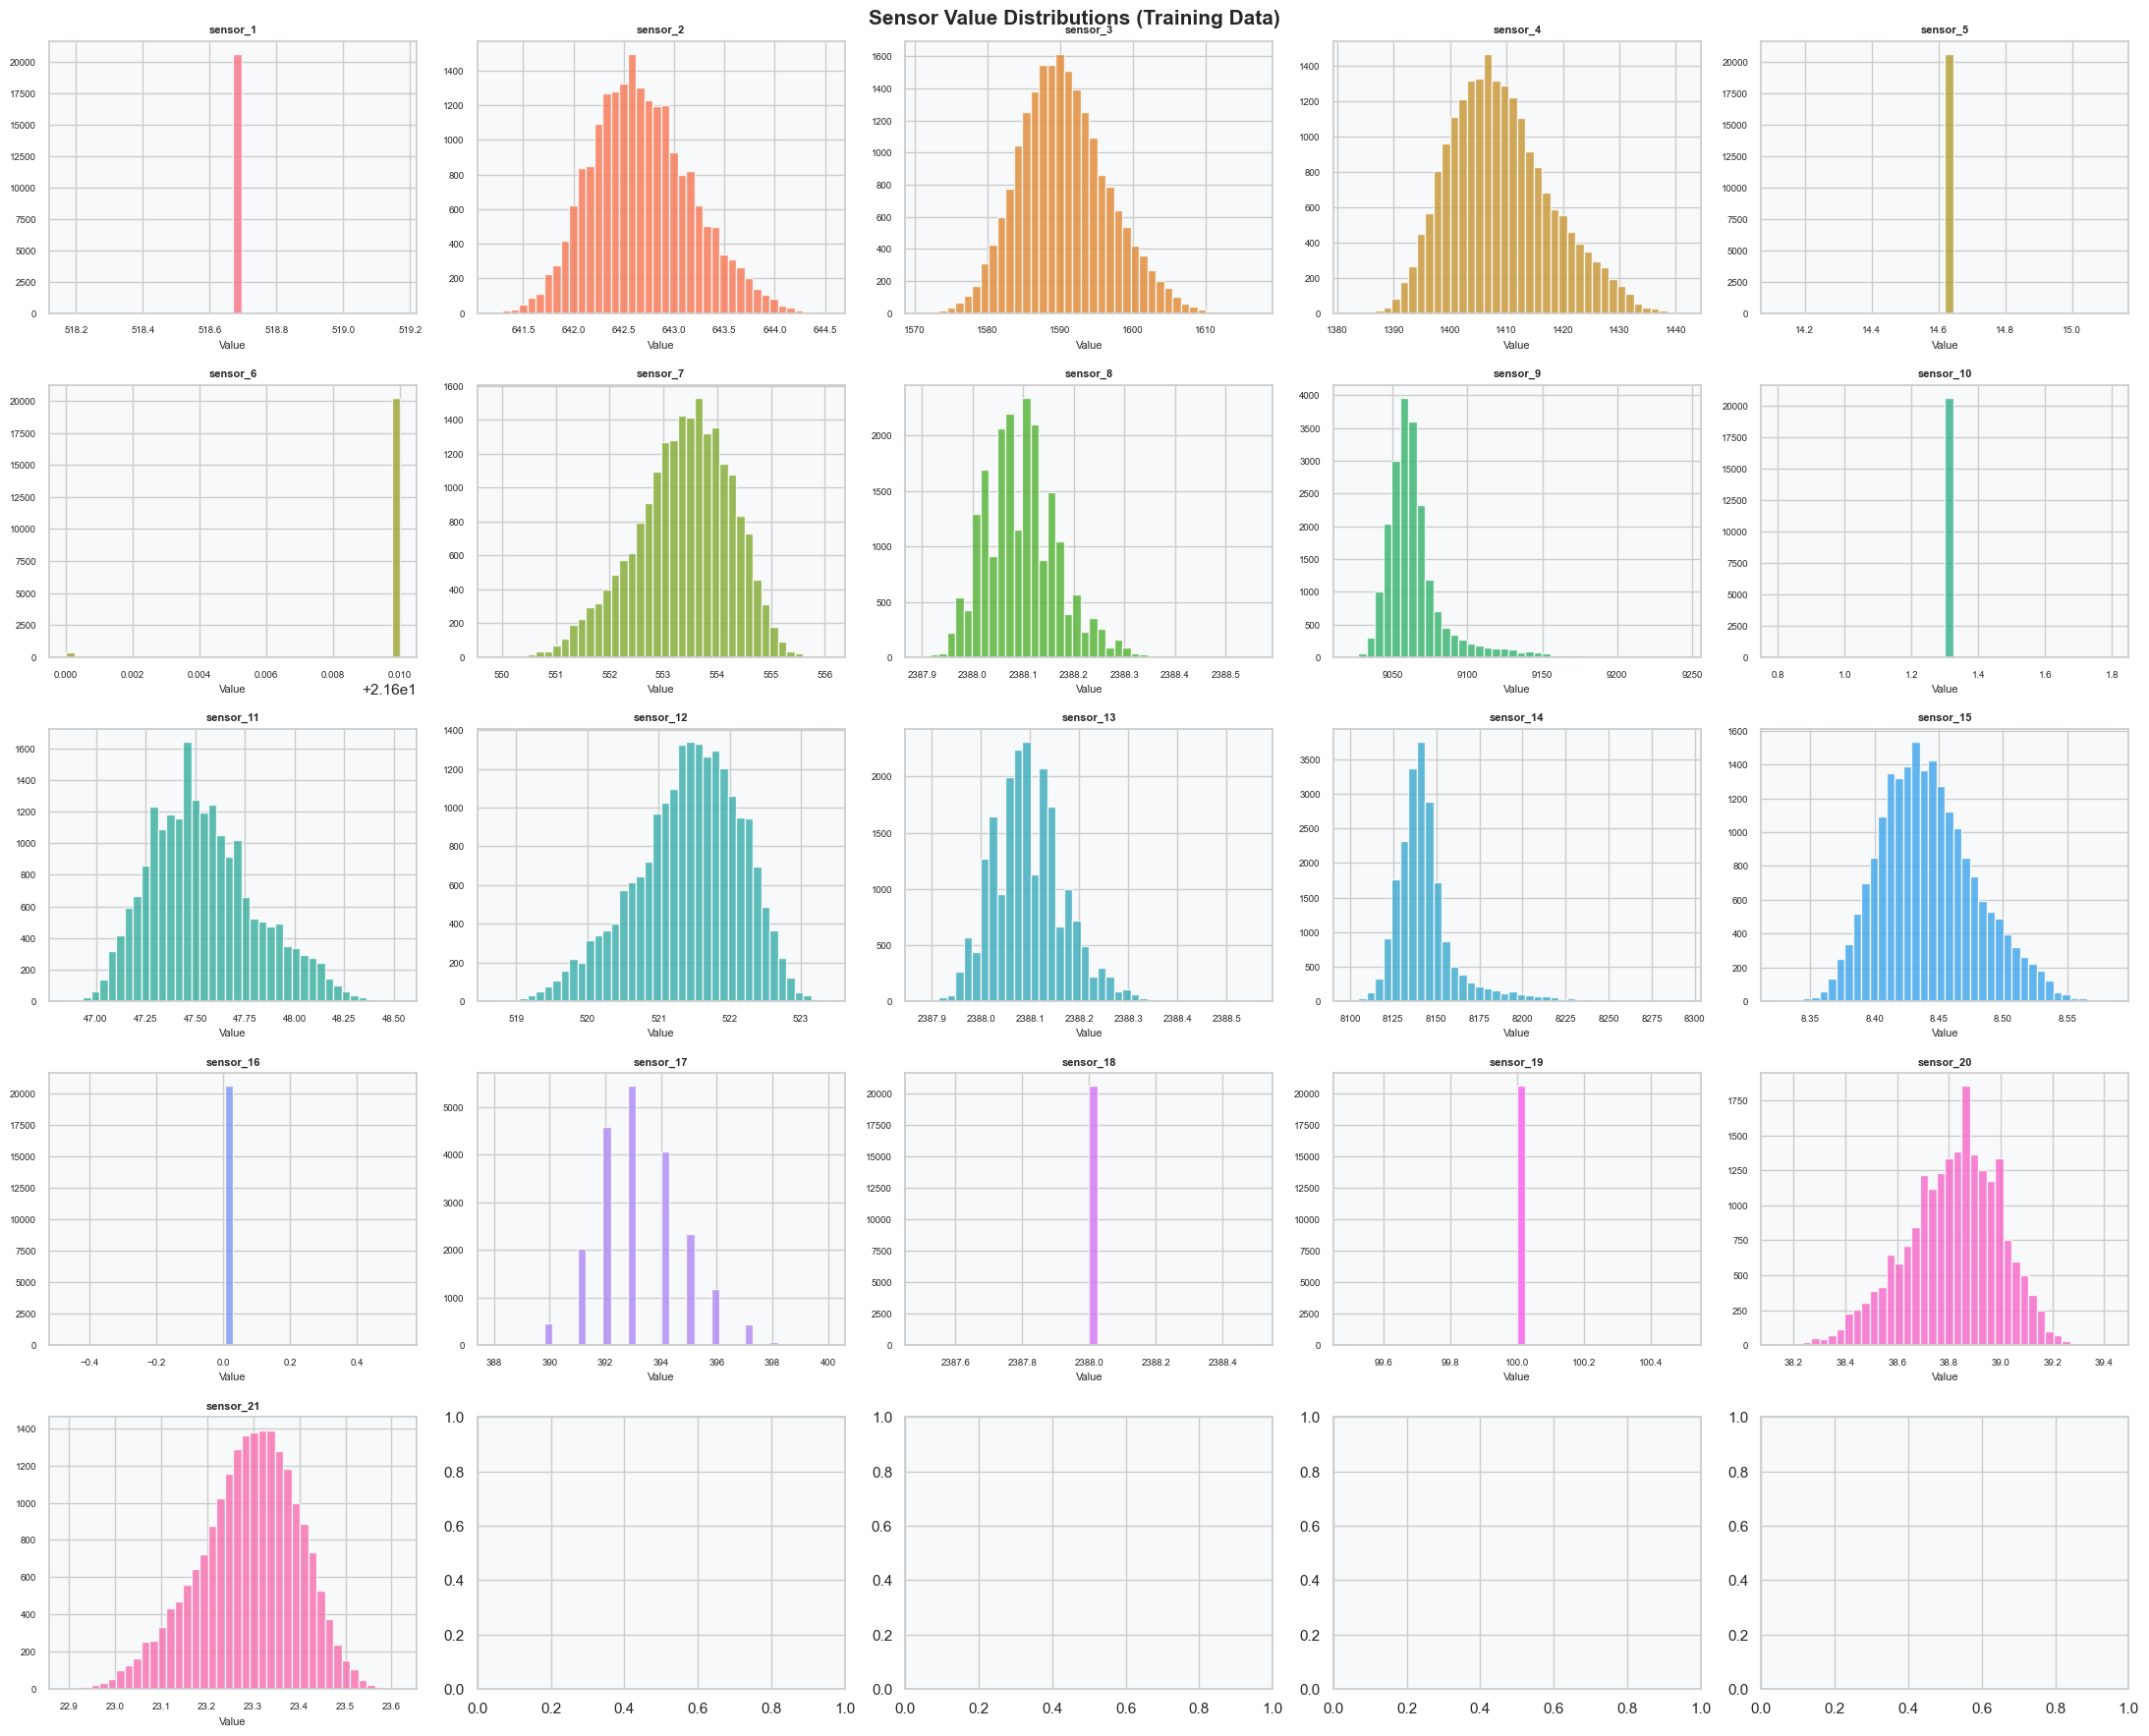

In [16]:
palette = sns.color_palette('husl',21)

fig, axes = plt.subplots(5, 5, figsize=(22, 18))
fig.suptitle(f'Sensor Value Distributions (Training Data)', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].hist(train_df[col], bins=40, color=palette[i], alpha=0.8, edgecolor='white')
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel('Value', fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(21, 25):
    axes[j].set_label(False)

plt.tight_layout()
plt.show()

### Key Observations

- **Constant Sensors**: sensor_16, sensor_18, sensor_19 and potentially other show near-zero variance.
- **Informative Sensors**: sensor_2, sensor_3, sensor_4, sensor_7, sensor_8, sensor_9, sensor_11-15, sensor_17, sensor_20, sensor_21 show meaningful spread.
- **Multi-modal distributions**: Some sensors show bimodal patterns suggesting noise interference.

### Potential Feature Selection Decisions
1. Drop constant sensors - zero information gain.
2. Normalize high-variance sensors - magnitudes differ by orders of magnitude.
3. Apply rolling smoothing to noisy before modelling.

## 10. Sensor Trend Analysis Across Engine Life

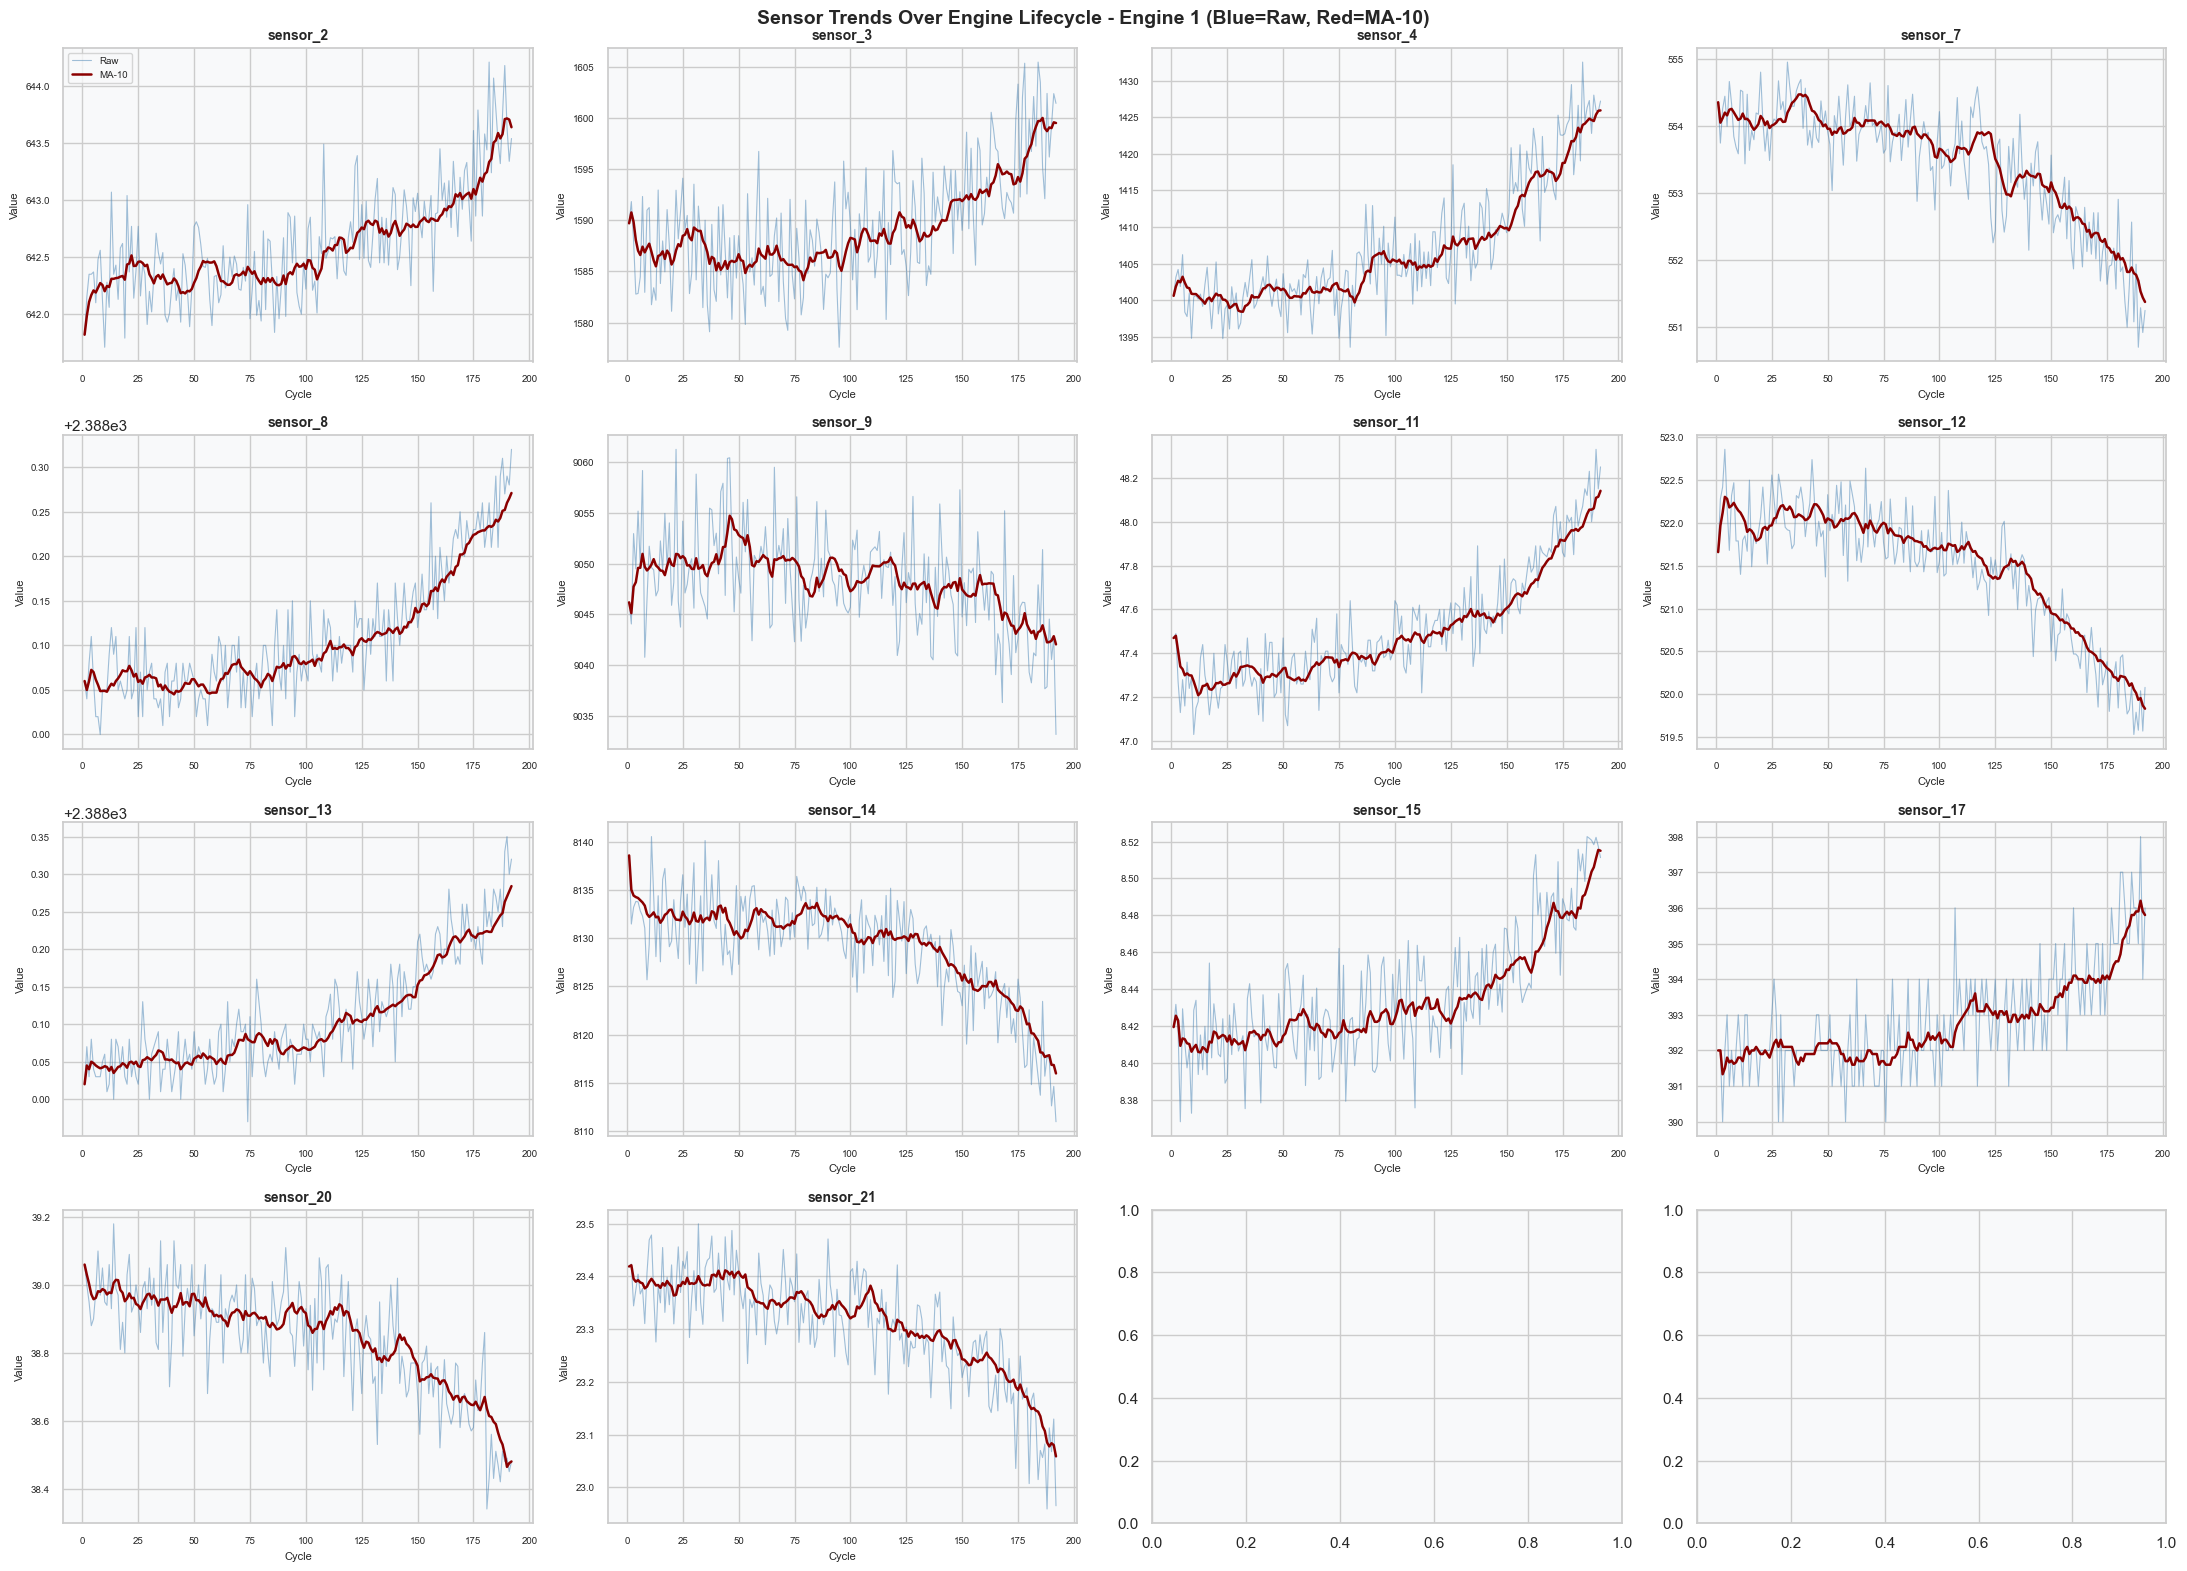

In [ ]:
key_sensors = ['sensor_2','sensor_3','sensor_4','sensor_7','sensor_8','sensor_9','sensor_11','sensor_12','sensor_13','sensor_14','sensor_15','sensor_17','sensor_20','sensor_21']

sample_engines = train_df[train_df['engine_id'] == 1].copy()

fig, axes = plt.subplots(4, 4, figsize=(22, 16))
fig.suptitle('Sensor Trends Over Engine Lifecycle - Engine 1 (Blue=Raw, Red=MA-10)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(key_sensors):
    axes[i].plot(sample_engines['cycle'], sample_engines[col], color='steelblue', alpha=0.5, linewidth=0.8, label='Raw')
    rolling = sample_engines[col].rolling(window=10, min_periods=1).mean()
    axes[i].plot(sample_engines['cycle'], rolling, color='darkred', linewidth=1.8, label='MA-10')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Cycle', fontsize=8)
    axes[i].set_ylabel('Value', fontsize=8)
    axes[i].tick_params(labelsize=7)

    if i == 0:
        axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

### Observations
- **Clear degradation trend**: sensor_2, sensor_3, sensor_4, sensor_7, sensor_8, sensor_11-15, sensor_17, sensor_20, sensor_21 show monotonic trends.
- **Stable Sensors**: sensor_1, sensor_5, sensor_6, sensor_9, sensor_10, sensor_16, sensor_18, sensor_19 - flat throughout lifecycle.
- **Noise**: All sensors have cycle-to-cycle noise. Rolling average (red) reveals the underlying trends.

### Importance for Predictive Maintainance
Sensors showing clear degradation trends are the **primary predictive signals** for RUL. The 10-cycle rolling average is a baseline feature engineering step that should be applied before modelling.

---
## 11. Multi-Engine Sensor Comparision

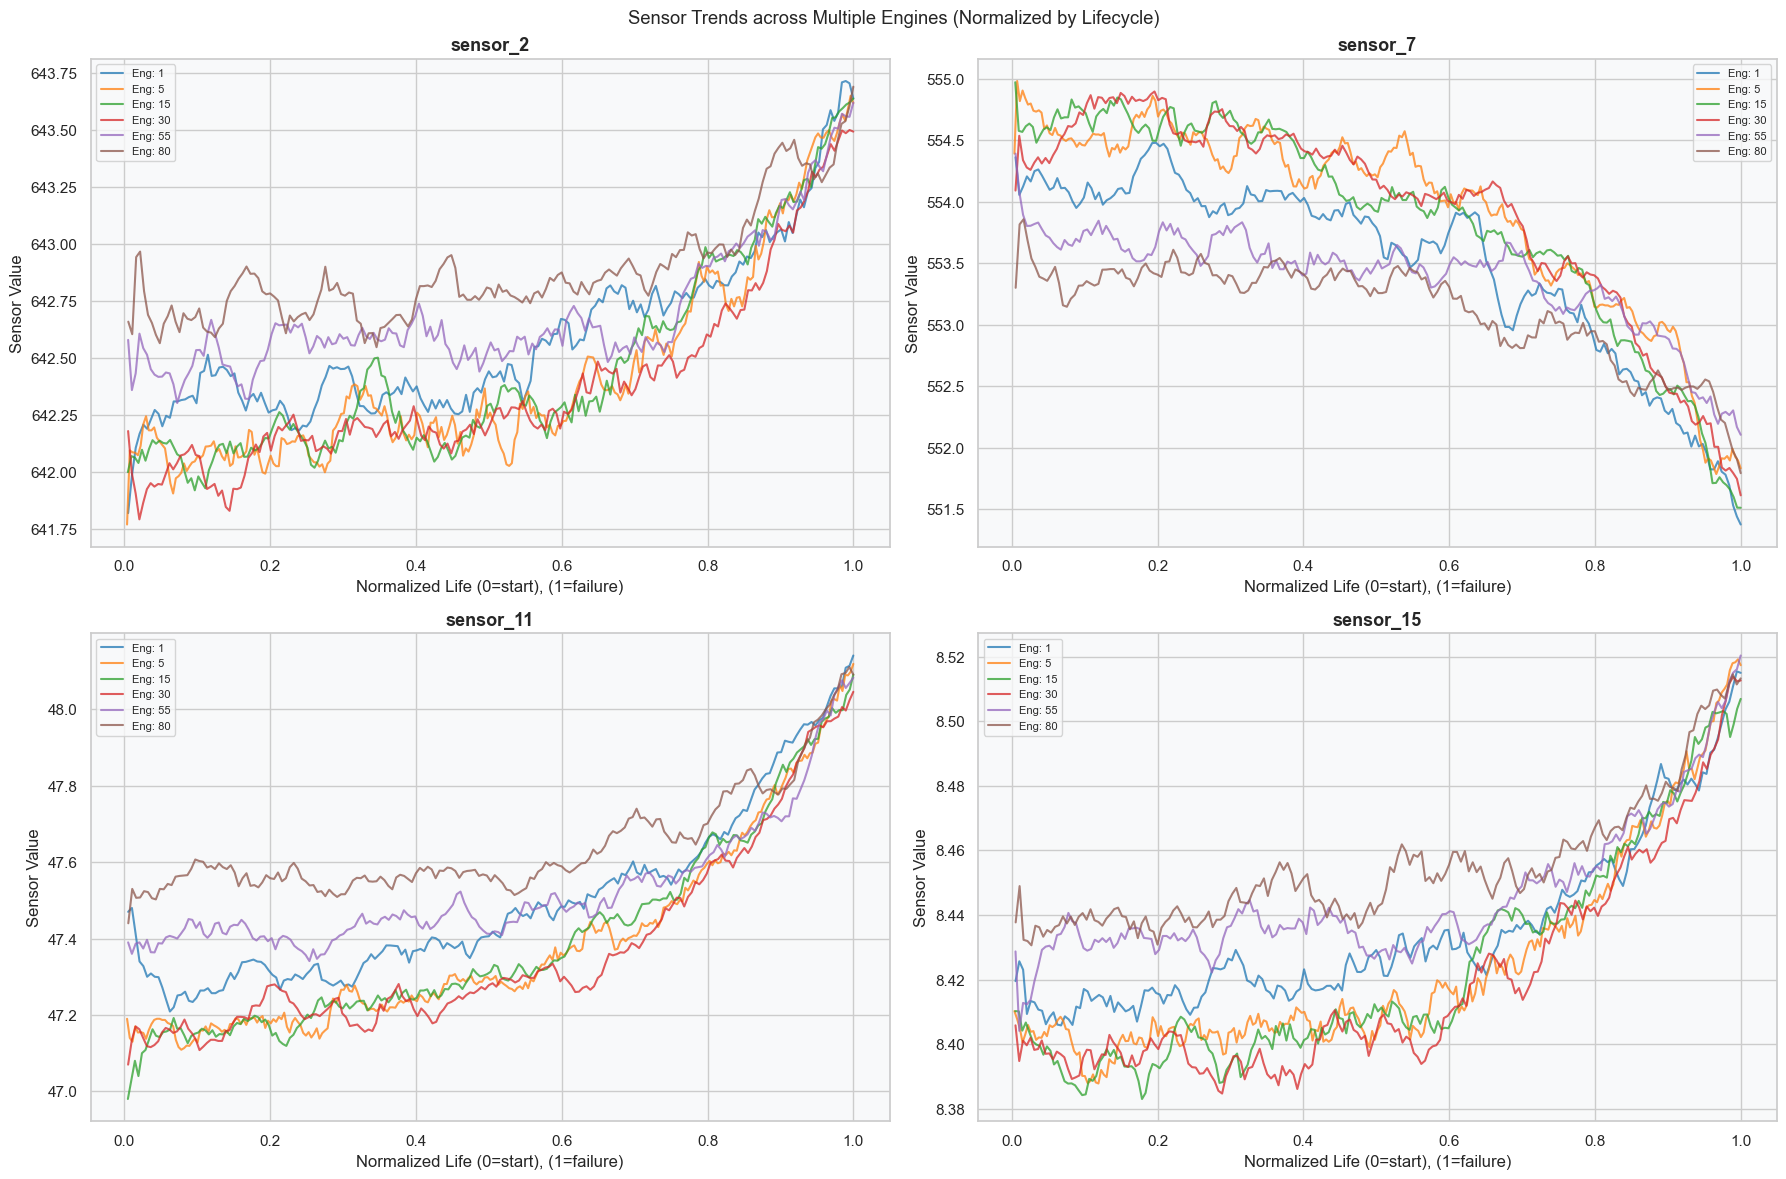

In [18]:
comparision_sensors = ['sensor_2', 'sensor_7', 'sensor_11', 'sensor_15']
comparision_engines = [1, 5, 15, 30, 55, 80]
colors_eng = sns.color_palette('tab10', len(comparision_engines))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Sensor Trends across Multiple Engines (Normalized by Lifecycle)')
axes = axes.flatten()

for i, sensor in enumerate(comparision_sensors):
    for j, eid in enumerate(comparision_engines):
        sub = train_df[train_df['engine_id'] == eid].copy()
        max_cycle = sub['cycle'].max()
        sub['cycle_norm'] = sub['cycle'] / max_cycle
        rolling = sub[sensor].rolling(10, min_periods=1).mean()
        axes[i].plot(sub['cycle_norm'], rolling, color=colors_eng[j], alpha=0.75, linewidth=1.5, label=f'Eng: {eid}')
    
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Normalized Life (0=start), (1=failure)')
    axes[i].set_ylabel('Sensor Value')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Businees Interpretation
By normalizing each engine's lifecycle to 0-1, we compare degradation on a common scale.
- **Consistent Patterns**: Key sensors show **similar trend shapes** across engines - the degradation mechanism is consistent.
- **Offset Variation**: Individual engines start at slightly different values reflecting manufacturing variation.

### Generalization Implication
Consistent trends are excellent news - the model can generalize from training to unseen test engines. However, initial-value offsets mean per-engine normalization (subtract first-cycle baseline) could improve accuracy.

## 12. Correlational Analysis

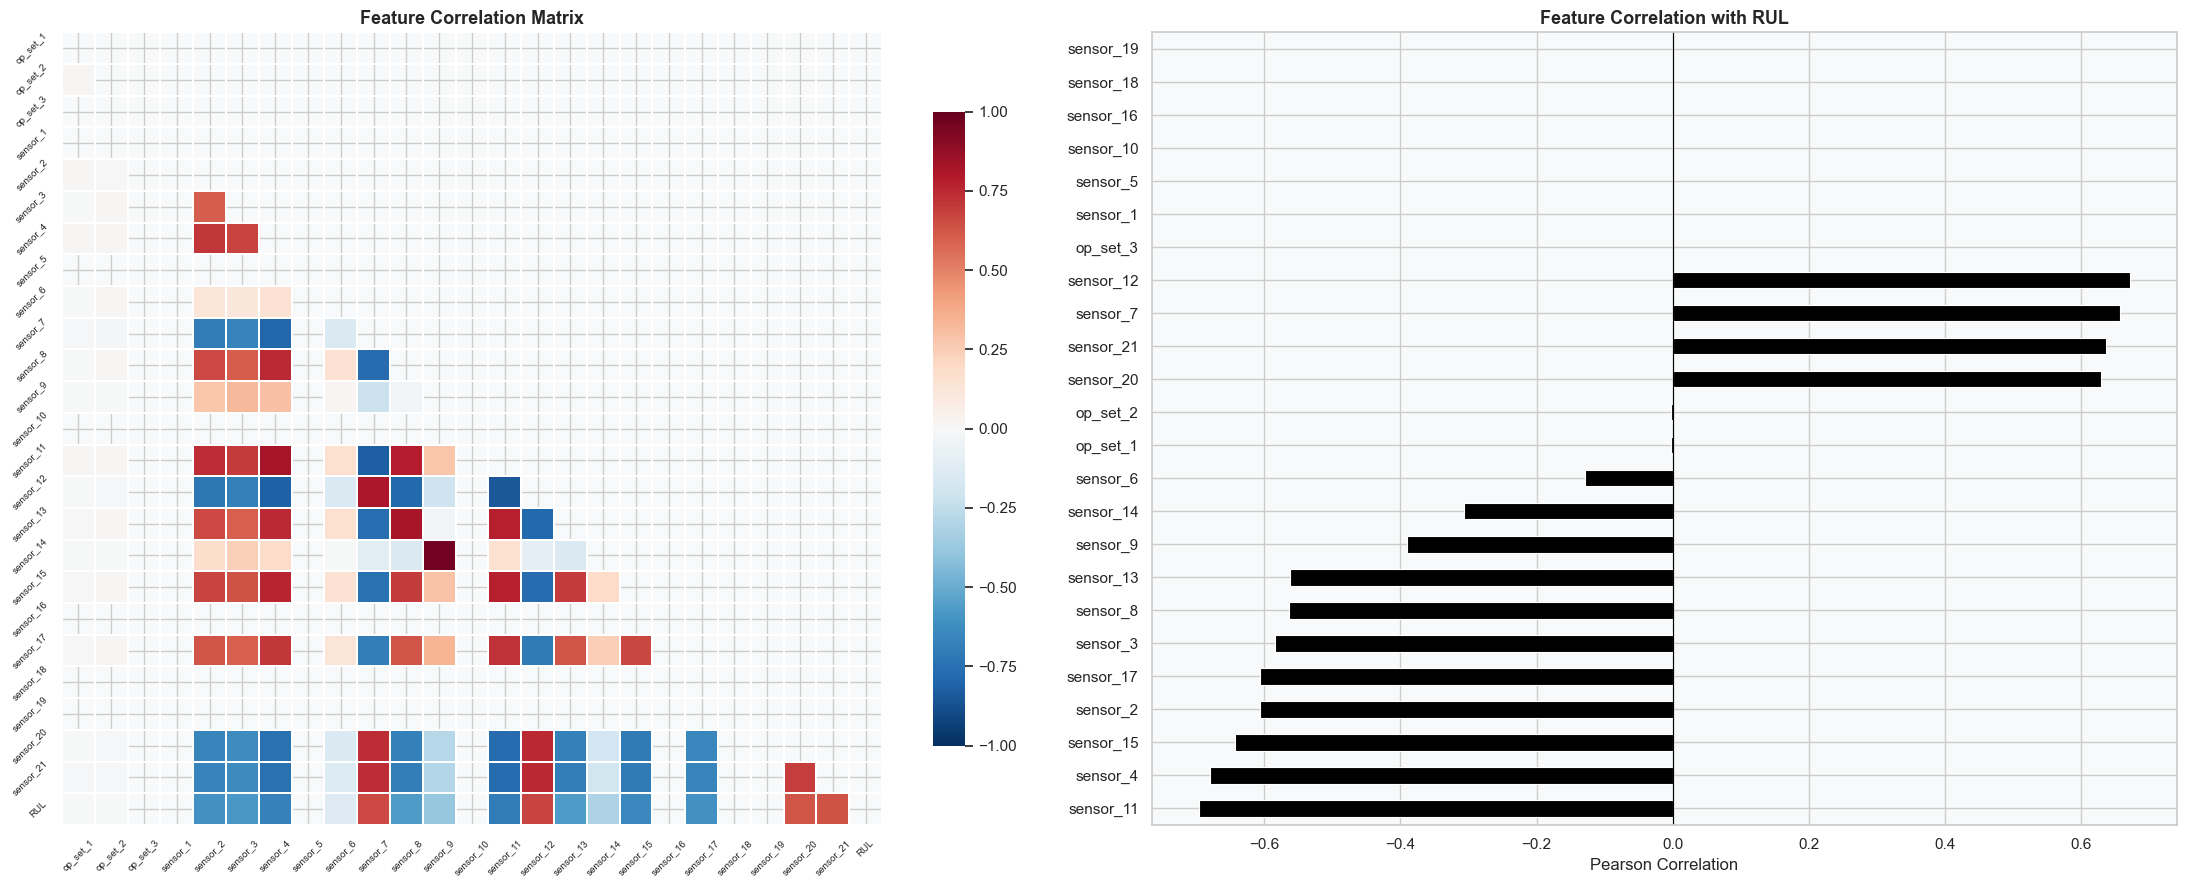

TOP POSITIVELY CORRELATED WITH RUL:
sensor_12    0.672
op_set_3       NaN
sensor_1       NaN
sensor_5       NaN
sensor_10      NaN
sensor_16      NaN
sensor_18      NaN
sensor_19      NaN

TOP NEGATIVELY CORRELATED WITH RUL:
sensor_11   -0.696
sensor_4    -0.679
sensor_15   -0.643
sensor_2    -0.606
sensor_17   -0.606
sensor_3    -0.585
sensor_8    -0.564
sensor_13   -0.563


In [19]:
feature_cols = op_cols + sensor_cols
corr_matrix = train_df[feature_cols + ['RUL']].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=axes[0], linewidths=0.3, cbar_kws={'shrink':0.8})
axes[0].set_title('Feature Correlation Matrix', fontsize=13)
axes[0].tick_params(labelsize=7, rotation=45)

rul_corr = corr_matrix['RUL'].drop('RUL').sort_values()
colors_bar = ['tomato' if v<0 else 'steelblue' for v in rul_corr]
rul_corr.plot(kind='barh', color='black', linewidth=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with RUL', fontsize=13)
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

print('TOP POSITIVELY CORRELATED WITH RUL:')
print(rul_corr.tail(8).round(3).to_string())
print()
print('TOP NEGATIVELY CORRELATED WITH RUL:')
print(rul_corr.head(8).round(3).to_string())

### Top Positively Correlated Features with RUL

High Positive Correlation = sensor value is higher and decreases as failure approaches

### Top Negatively Correlated Features with RUL

High Negative Correlation = sensor value increases as failure approaches

### Why Correlation alone should not drive Feature Selection

1. **Linear Assumption**: Pearson Correlation captures only linear relationships. Nonlinear degradation may show low Pearson Correlation but high predicitve value.
2. **Noise Masking**: Noisy sensors may have true correlation obscured by cycle-to-cyle variance.
3. **Redundancy**: Two correlated sensors may carry the same information.
4. **Better Alternatives**: Use SHAP importance or domain expertise.

---
## 13. Sensor Monotonocity Analysis

In [20]:
def monotonocity_scores(series):
    diffs = np.diff(series.values)

    if len(diffs) == 0:
        return 0.0
    
    pos = (diffs > 0).sum()
    neg = (diffs < 0).sum()

    return max(pos, neg) / len(series)

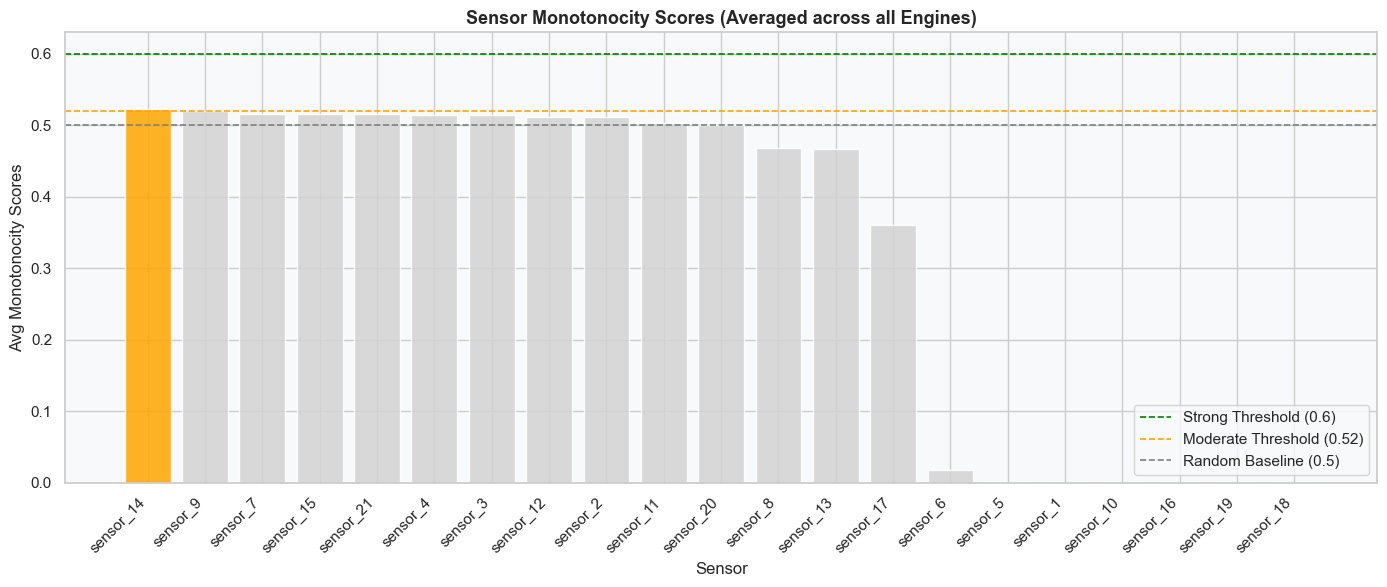

MONTONOCITY RANKING
sensor_14: 0.5232290668442676 [MODERATE]
sensor_9: 0.5196647877214279 [WEAK]
sensor_7: 0.5159255139606418 [WEAK]
sensor_15: 0.5158394412557016 [WEAK]
sensor_21: 0.5151626074341354 [WEAK]
sensor_4: 0.5147698112398679 [WEAK]
sensor_3: 0.513639818974954 [WEAK]
sensor_12: 0.5115496030930068 [WEAK]
sensor_2: 0.5114317783755514 [WEAK]
sensor_11: 0.5030965895303804 [WEAK]
sensor_20: 0.5008451779371436 [WEAK]
sensor_8: 0.46834576433670727 [WEAK]
sensor_13: 0.46726394884704464 [WEAK]
sensor_17: 0.36040382947634714 [WEAK]
sensor_6: 0.016817537651629976 [WEAK]
sensor_5: 0.0 [WEAK]
sensor_1: 0.0 [WEAK]
sensor_10: 0.0 [WEAK]
sensor_16: 0.0 [WEAK]
sensor_19: 0.0 [WEAK]
sensor_18: 0.0 [WEAK]


In [21]:
mono_scores = {}

for sensor in sensor_cols:
    scores = [monotonocity_scores(grp[sensor]) for _, grp in train_df.groupby('engine_id')]
    mono_scores[sensor] = np.mean(scores)

mono_df = pd.Series(mono_scores).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
colors_mono = ['steelblue' if v > 0.6 else ('orange' if v > 0.52 else 'lightgray') for v in mono_df]
plt.bar(mono_df.index, mono_df.values, color=colors_mono, alpha=0.85, edgecolor='white')
plt.axhline(0.6, color='green', linestyle='--', linewidth=1.2, label='Strong Threshold (0.6)')
plt.axhline(0.52, color='orange', linestyle='--', linewidth=1.2, label='Moderate Threshold (0.52)')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Random Baseline (0.5)')
plt.xlabel('Sensor')
plt.ylabel('Avg Monotonocity Scores')
plt.title('Sensor Monotonocity Scores (Averaged across all Engines)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.legend()
plt.tight_layout()
plt.show()

print('MONTONOCITY RANKING')
for s, v in mono_df.items():
    tag = 'STRONG' if v > 0.60 else ('MODERATE' if v > 0.52 else 'WEAK')
    print(f'{s}: {v} [{tag}]')

### Key Findings
- **Strong degradation indicators** (monotonocity > 0.60): Consistently trend in one direction as failure approaches.
- **Weak Indicators** (<= 0.52): Oscillate without consistent direction - likely noise-dominated

### Modelling Relevance
Monotonocity is a domain-aware quality metric for PHM (Prognostics and Health Management). High-monotonocity sensors are preferred for feature selection and constructing health index derived features.

---
## 14. Early, Mid and Late Lifecycle Analysis

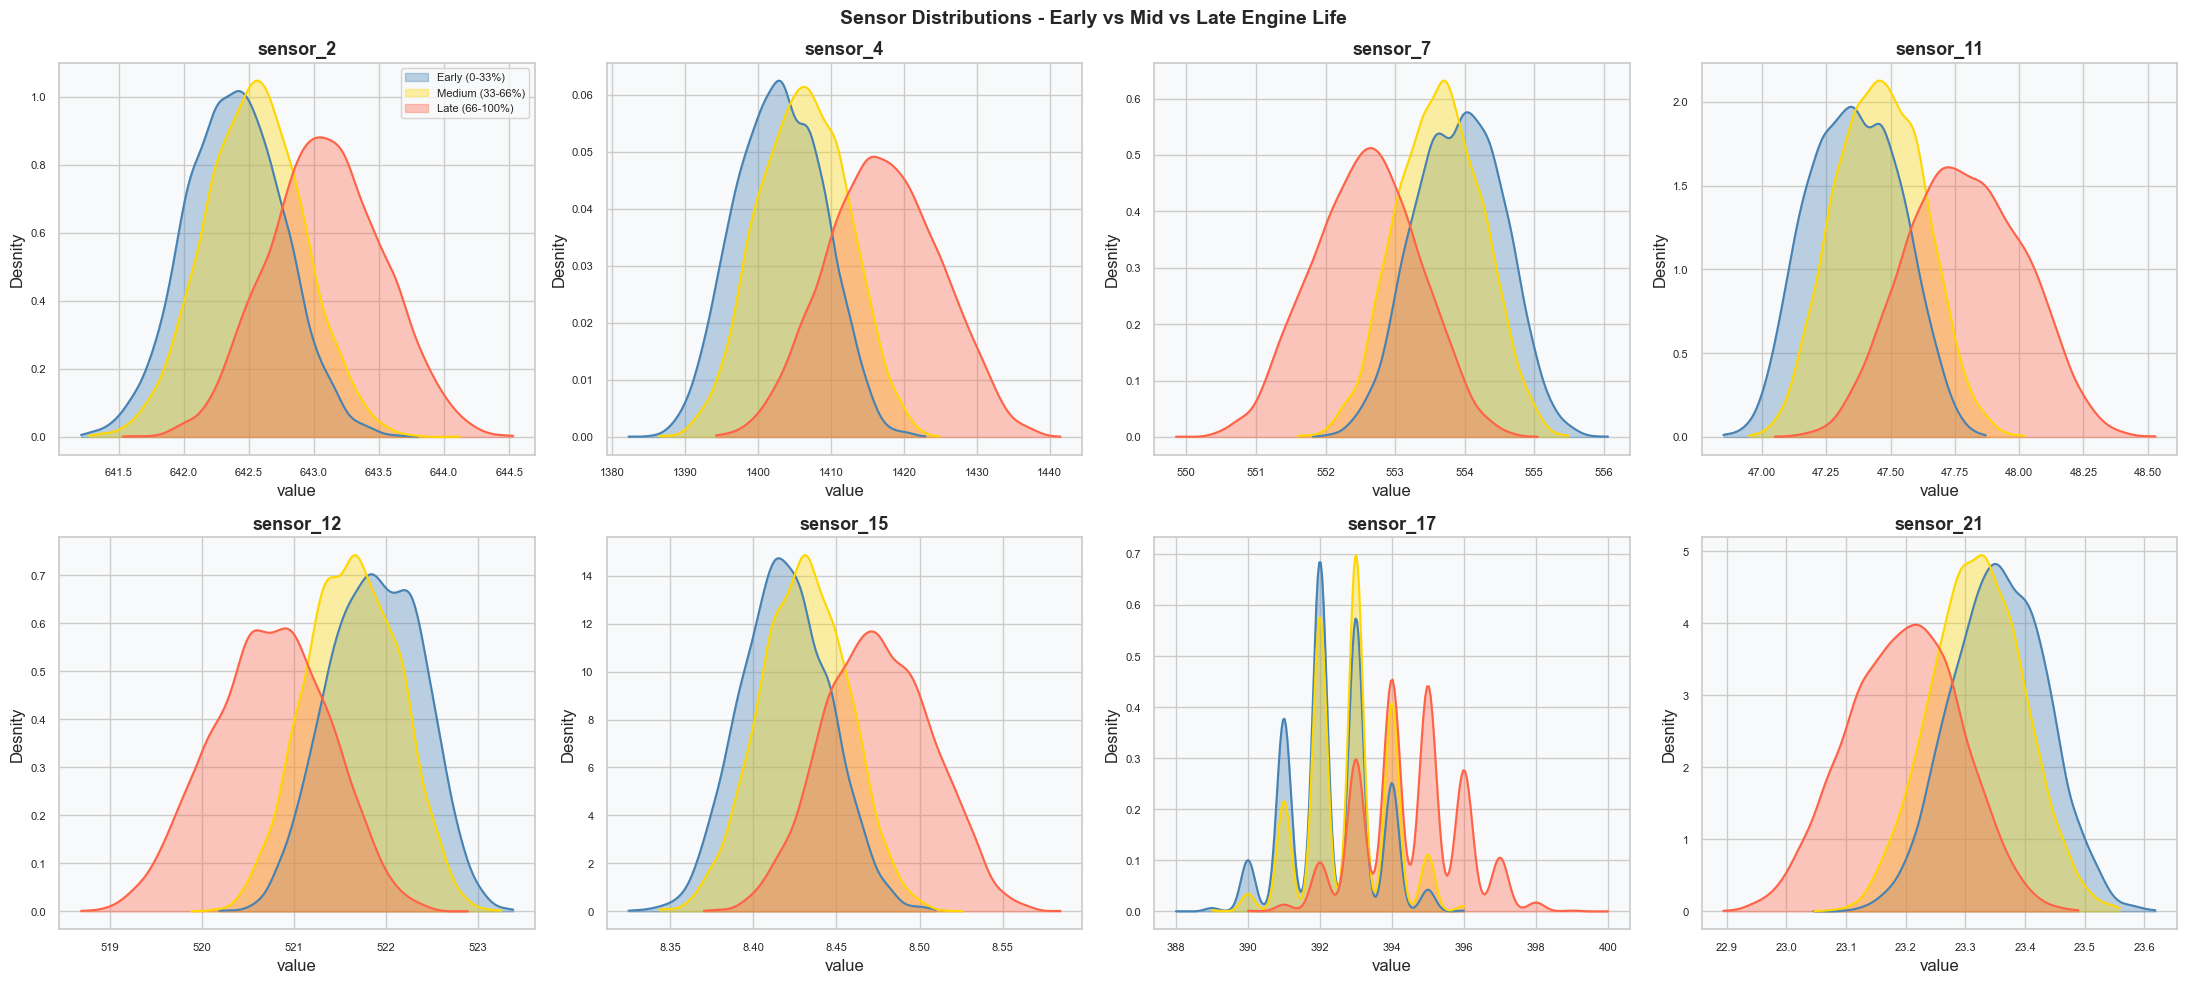

MEAN SENSOR VALUES BY LIFE STAGE
                 sensor_2  sensor_4  sensor_7  sensor_11  sensor_12  sensor_15  sensor_17  sensor_21
life_stage                                                                                          
Early (0-33%)     642.391  1402.993   553.923     47.361    521.892      8.419    392.299     23.357
Medium (33-66%)   642.541  1406.224   553.638     47.459    521.637      8.431    392.777     23.320
Late (66-100%)    643.093  1417.237   552.574     47.792    520.740      8.475    394.502     23.196


In [22]:
train_df['life_norm'] = train_df.groupby('engine_id')['cycle'].transform(lambda x: x / x.max())
train_df['life_stage'] = pd.cut(train_df['life_norm'], bins=[0.0, 0.33, 0.66, 1.0], labels=['Early (0-33%)', 'Medium (33-66%)', 'Late (66-100%)'], include_lowest=True)

stage_sensors = ['sensor_2','sensor_4','sensor_7','sensor_11','sensor_12','sensor_15','sensor_17','sensor_21']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

fig.suptitle('Sensor Distributions - Early vs Mid vs Late Engine Life', fontsize=14, fontweight='bold')
axes = axes.flatten()
stage_palette = {'Early (0-33%)':'steelblue','Medium (33-66%)':'gold','Late (66-100%)':'tomato'}

for i, sensor in enumerate(stage_sensors):
    for stage, color in stage_palette.items():
        subset = train_df[train_df['life_stage'] == stage][sensor]

        if subset.std() > 0:
            vals = subset.dropna().values
            kde_s = gaussian_kde(vals)
            x_range = np.linspace(vals.min(), vals.max(), 200)
            axes[i].fill_between(x_range, kde_s(x_range), alpha=0.35, color=color, label=stage)
            axes[i].plot(x_range, kde_s(x_range), color=color, linewidth=1.5)
        
        axes[i].set_title(sensor)
        axes[i].set_xlabel('value')
        axes[i].set_ylabel('Desnity')
        axes[i].tick_params(labelsize=8)

        if i == 0:
            axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('MEAN SENSOR VALUES BY LIFE STAGE')
print(train_df.groupby('life_stage')[stage_sensors].mean().round(3).to_string())

### Observations

- **Degradation Sensors** show clear shifted distributions across Early, Mid and Low.
- **Stable Sensors** show near-identical distributions confirming no lifecycle information.
- The **Late Stage** distribution is the most distinct - most rapid degradation in final third.

### Predictive Signals Emerging Near Failures
Distribution shifts in Late stage are the primary signals the model will learn. The gap between Early and Late distributions is a proxy for each sensor's predictive power. This motivates rolling statistics (mean, std, min, max over a window) as features.

---

## 15. Feature Importance Recommendations

In [25]:
high_value = ['sensor_2','sensor_3','sensor_4','sensor_7','sensor_8','sensor_9',
              'sensor_11','sensor_12','sensor_13','sensor_14','sensor_15',
              'sensor_17','sensor_20','sensor_21']
removable  = ['sensor_1','sensor_5','sensor_6','sensor_10','sensor_16','sensor_18','sensor_19','op_set_3']

print('FEATURE IMPORTANCE RECOMMENDATIONS')
print('='*60)
print()
print(f'[HIGH-VALUE] Strong degradation signal ({len(high_value)} sensors):')
for s in high_value: 
    print(f'{s}')
print()
print(f'[REMOVABLE] Constant or near-constant ({len(removable)} features):')
for s in removable:
    print(f'{s}')

FEATURE IMPORTANCE RECOMMENDATIONS

[HIGH-VALUE] Strong degradation signal (14 sensors):
sensor_2
sensor_3
sensor_4
sensor_7
sensor_8
sensor_9
sensor_11
sensor_12
sensor_13
sensor_14
sensor_15
sensor_17
sensor_20
sensor_21

[REMOVABLE] Constant or near-constant (8 features):
sensor_1
sensor_5
sensor_6
sensor_10
sensor_16
sensor_18
sensor_19
op_set_3


### Summary

| Category | Sensors | Reasoning |
|---|---|---|
| High-value | sensor_2,3,4,7,8,9,11,12,13,14,15,17,20,21 | Strong monotonicity + correlation + distribution shift |
| Removable | sensor_1,5,6,10,16,18,19, op_set_3 | Near-zero variance, no degradation signal |

---
## 16. Summary

### Aircraft Engine Health Monitoring - What we Found

We analyzed real-time sensor data from **100 aircraft engines** run until failure in a controlled simulation.
___

#### 1. What did we learn about Engine Degradation?

As an aircraft engine approaches failure, measurable changes occur across multiple sensors. We identifies **14 out of 21 sensors** that show consistent, predictable degradation patterns. The remaining 7 sensors are essentially silent - they do not change as the engine degrades.

Degradation is gradual: engines behave normally for most of their life, then show **accelerating change in the final third** of their operational life

____

#### 2. Which Sensors appears most Useful?
14 sensors reliably signal engine health decline. The remaining 7 sensors are static and can be safely ignored.

___

#### 3. What Challenges exists in the Dataset?
- **Sensor Noise**: All sensors contain random measurement noise. Smooting techniques are required before modelling.
- **Engine-to-Engine Variation**: Engines start life in slightly different conditions. The model must account for this.

___

#### 4. What Preprocessing is required?
Three main steps:
1. **Remove uninformative sensors**: drop the 7 salient features.
2. **Smooth the data**: apply rolling functions to reduce noise.
3. **Normalize Values**: ensure all sensor readings are on a comparable scale.